In [2]:
%pip install gradio

  Using cached gradio-6.27.0-py3-none-any.whl.metadata (17 kB)
  Using cached fastapi-0.141.1-py3-none-any.whl.metadata (27 kB)
  Using cached gradio_client-2.7.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
Using cached gradio-6.27.0-py3-none-any.whl (31.3 MB)
Using cached gradio_client-2.7.0-py3-none-any.whl (63 kB)
Using cached fastapi-0.141.1-py3-none-any.whl (131 kB)
Using cached hf_gradio-0.4.1-py3-none-any.whl (4.5 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 13.9 MB/s  0:00:00

   ----------------------------------------  0/17 [pytz]
   ----------------------------------------  0/17 [pytz]
   -- -------------------------------------  1/17 [pydub]
   ---- -----------------------------------  2/17 [brotli]
   --------- ------------------------------  4/17 [tomlkit]
   ----------- ----------------------------  5/17 [semantic-version]
   ----


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import gradio as gr

print("Gradio version:", gr.__version__)

Gradio version: 6.27.0


In [4]:
import gradio as gr

demo = gr.Interface(
    fn=lambda image: image,
    inputs=gr.Image(
        type="pil",
        label="Upload Road Image"
    ),
    outputs=gr.Image(
        type="pil",
        label="Output"
    ),
    title="Mini ADAS Vision"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.detector import ObjectDetector
from src.analyzer import ADASAnalyzer

In [6]:
from PIL import Image

image = Image.open("../images/road.jpg")

detector = ObjectDetector()

detections = detector.detect(image)

print("Detections:", len(detections))

Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Detections: 50


In [7]:
analyzer = ADASAnalyzer(detections)

analysis = analyzer.analyze(
    image.width,
    image.height
)

print(analysis.keys())

dict_keys(['object_counts', 'spatial_results', 'warnings'])


In [8]:
print("Warnings:")

for warning in analysis["warnings"]:
    print(warning)

Warnings:
HIGH: 9 pedestrians in ego-lane
HIGH: 16 cars in ego-lane
HIGH: Truck in ego-lane
HIGH: 2 motorcycles in ego-lane


In [9]:
def analyze_image(image):
    """
    Run the Mini ADAS detection and risk-analysis pipeline.
    """

    if image is None:
        return "Please upload a road image."

    # Object detection
    detector = ObjectDetector()
    detections = detector.detect(image)

    # ADAS analysis
    analyzer = ADASAnalyzer(detections)

    analysis = analyzer.analyze(
        image.width,
        image.height
    )

    # Build warning text
    warnings = analysis["warnings"]

    if warnings:
        warning_text = "\n".join(
            f"⚠ {warning}"
            for warning in warnings
        )
    else:
        warning_text = "No significant warnings."

    return warning_text

In [10]:
warning_text = analyze_image(image)

print(warning_text)

Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⚠ HIGH: 9 pedestrians in ego-lane
⚠ HIGH: 16 cars in ego-lane
⚠ HIGH: Truck in ego-lane
⚠ HIGH: 2 motorcycles in ego-lane


In [11]:
import gradio as gr

demo = gr.Interface(
    fn=analyze_image,
    inputs=gr.Image(
        type="pil",
        label="Upload Road Image"
    ),
    outputs=gr.Textbox(
        label="ADAS Warnings"
    ),
    title="Mini ADAS Vision"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
import io
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from PIL import Image

In [13]:
def create_annotated_image(
        image,
        spatial_results,
        danger_zone
):
    """
    Create an annotated ADAS image and return it as a PIL image.

    This function is designed for UI output.
    """

    width = image.width
    height = image.height

    # Convert normalized danger-zone coordinates
    zone_points = [
        (
            x * width,
            y * height
        )
        for x, y in danger_zone
    ]

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    ax.imshow(image)

    # Draw ego-lane
    polygon = Polygon(
        zone_points,
        closed=True,
        fill=False,
        linewidth=3
    )

    ax.add_patch(polygon)

    # Keep relevant detections
    relevant = [
        detection
        for detection in spatial_results
        if detection["risk_level"] in {
            "MEDIUM",
            "HIGH"
        }
    ]

    # Highest risk first
    relevant.sort(
        key=lambda detection: detection["risk_score"],
        reverse=True
    )

    # Draw detections
    for index, detection in enumerate(relevant):

        label = detection["label"]
        confidence = detection["score"]

        xmin, ymin, xmax, ymax = detection["box"]

        center_x, center_y = detection["center"]

        bottom_x, bottom_y = detection["bottom_center"]

        risk_level = detection["risk_level"]
        risk_score = detection["risk_score"]

        proximity = detection["proximity"]

        linewidth = 4 if risk_level == "HIGH" else 2

        rectangle = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=linewidth
        )

        ax.add_patch(rectangle)

        # Center point
        ax.scatter(
            center_x,
            center_y,
            s=30
        )

        # Bottom-center point
        ax.scatter(
            bottom_x,
            bottom_y,
            s=45
        )

        # Label top 5 detections
        if index < 5:

            text = (
                f"{label} {confidence:.2f}\n"
                f"{risk_level} | {proximity.upper()}\n"
                f"risk={risk_score:.2f}"
            )

            ax.text(
                xmin,
                max(5, ymin - 5),
                text,
                fontsize=9,
                verticalalignment="bottom",
                backgroundcolor="white"
            )

    # Summary
    high_count = sum(
        1
        for detection in spatial_results
        if detection["risk_level"] == "HIGH"
        and detection["inside_danger_zone"]
    )

    medium_count = sum(
        1
        for detection in spatial_results
        if detection["risk_level"] == "MEDIUM"
        and detection["inside_danger_zone"]
    )

    ego_lane_count = sum(
        1
        for detection in spatial_results
        if detection["inside_danger_zone"]
    )

    summary = (
        f"ADAS SUMMARY | "
        f"HIGH: {high_count} | "
        f"MEDIUM: {medium_count} | "
        f"EGO-LANE OBJECTS: {ego_lane_count}"
    )

    ax.text(
        0.02,
        0.97,
        summary,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        backgroundcolor="white"
    )

    ax.set_title(
        "Mini ADAS — Spatial Risk Analysis"
    )

    ax.axis("off")

    plt.tight_layout()

    # -----------------------------------------------
    # Convert Matplotlib figure → PIL image
    # -----------------------------------------------

    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format="png",
        bbox_inches="tight"
    )

    plt.close(fig)

    buffer.seek(0)

    annotated_image = Image.open(buffer).convert("RGB")

    return annotated_image

In [14]:
annotated_image = create_annotated_image(
    image,
    analysis["spatial_results"],
    analyzer.danger_zone
)

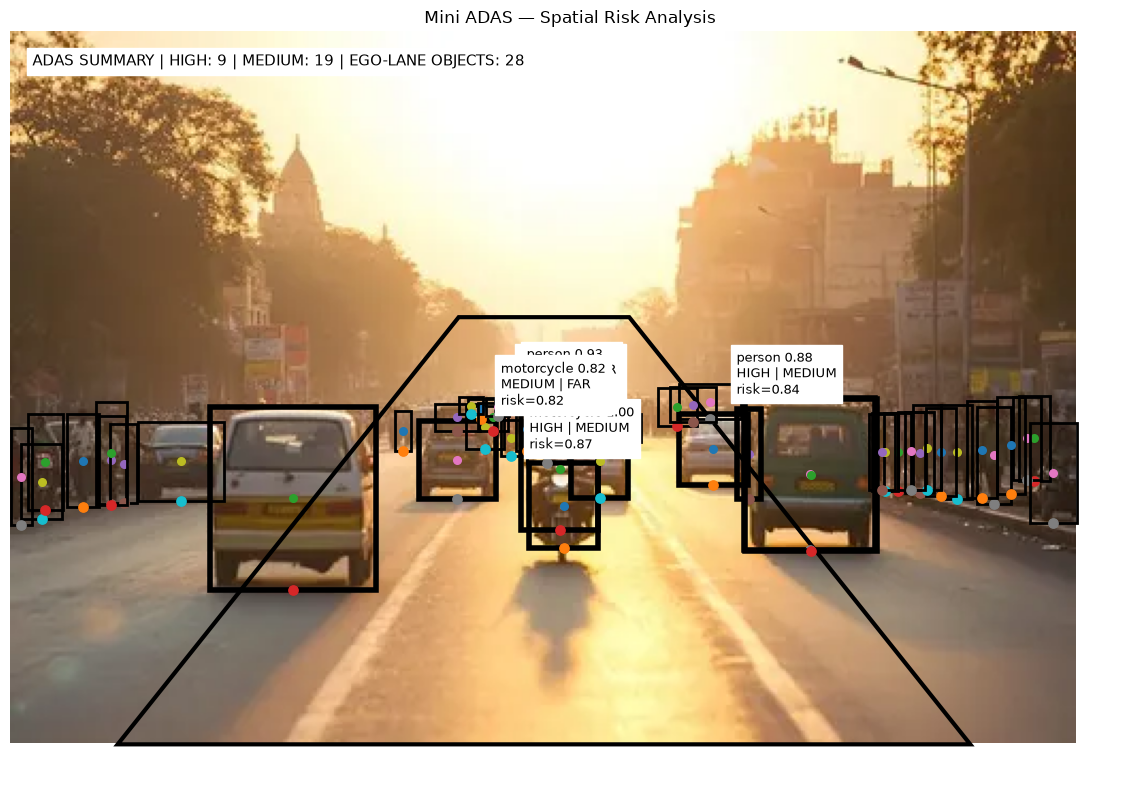

In [15]:
display(annotated_image)

In [16]:
def analyze_image(image):
    """
    Run the Mini ADAS pipeline and return:

    1. Annotated image
    2. ADAS warning summary
    """

    if image is None:
        return None, "Please upload a road image."

    # -----------------------------------------------
    # Object detection
    # -----------------------------------------------

    detector = ObjectDetector()

    detections = detector.detect(image)

    # -----------------------------------------------
    # ADAS analysis
    # -----------------------------------------------

    analyzer = ADASAnalyzer(detections)

    analysis = analyzer.analyze(
        image.width,
        image.height
    )

    # -----------------------------------------------
    # Create annotated image
    # -----------------------------------------------

    annotated_image = create_annotated_image(
        image,
        analysis["spatial_results"],
        analyzer.danger_zone
    )

    # -----------------------------------------------
    # Build warning output
    # -----------------------------------------------

    warnings = analysis["warnings"]

    if warnings:

        warning_text = "\n".join(
            f"⚠ {warning}"
            for warning in warnings
        )

    else:

        warning_text = (
            "No significant warnings."
        )

    return annotated_image, warning_text

In [17]:
import gradio as gr

demo = gr.Interface(
    fn=analyze_image,

    inputs=gr.Image(
        type="pil",
        label="Upload Road Image"
    ),

    outputs=[
        gr.Image(
            type="pil",
            label="ADAS Analysis"
        ),

        gr.Textbox(
            label="ADAS Warnings",
            lines=6
        )
    ],

    title="Mini ADAS Vision",

    description=(
        "Upload a road image to detect objects "
        "and perform simple spatial risk analysis."
    )
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
